**Program No. 08.  >> Scatter Plot Analysis**

**Objective:** To study relationships between two variables.
Tasks:
- Draw a scatter plot for study hours vs marks
- Analyze correlation

**Outcome:** Students will identify relationships between variables.


**Step 1:** Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

**Step 2:** Load and Prepare Dataset

In [2]:
# Load dataset
df = pd.read_csv("student_data.csv")

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Convert required columns to numeric
df["study_hours_per_day"] = pd.to_numeric(df["study_hours_per_day"], errors="coerce")
df["percentage"] = pd.to_numeric(df["percentage"], errors="coerce")

# Remove rows with missing values
df = df.dropna(subset=["study_hours_per_day", "percentage"])

# Verify data types
print(df[["study_hours_per_day", "percentage"]].dtypes)

study_hours_per_day    float64
percentage             float64
dtype: object


**Step 3:** Create Scatter Plot

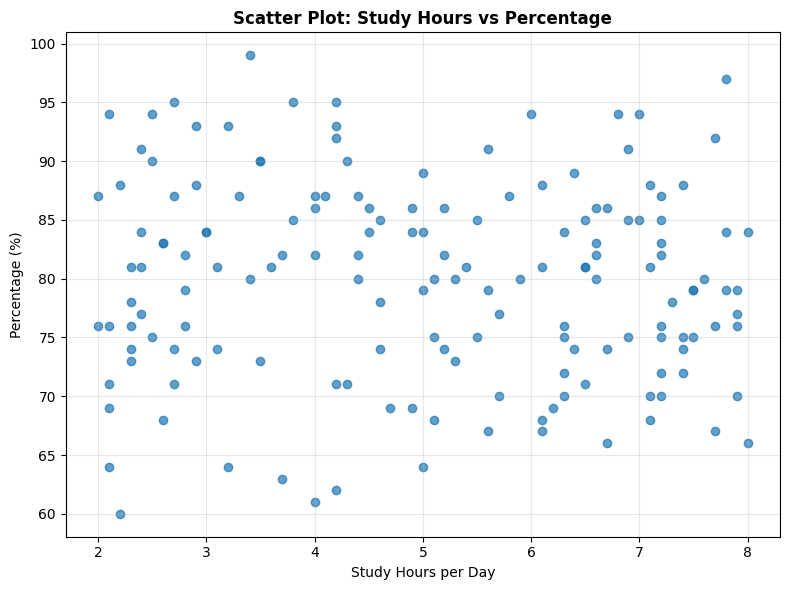

In [3]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["study_hours_per_day"],
    df["percentage"],
    alpha=0.7
)

plt.title("Scatter Plot: Study Hours vs Percentage", fontweight="bold")
plt.xlabel("Study Hours per Day")
plt.ylabel("Percentage (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Step 4:** Correlation Analysis

In [4]:
correlation = df["study_hours_per_day"].corr(df["percentage"])
print("Correlation Coefficient:", round(correlation, 3))

Correlation Coefficient: -0.062


**Expected Observation** (Based on Data Structure)
- Slight positive relationship expected
- Students who study more hours tend to score higher
- But other factors (stress, sleep, attendance) also influence marks

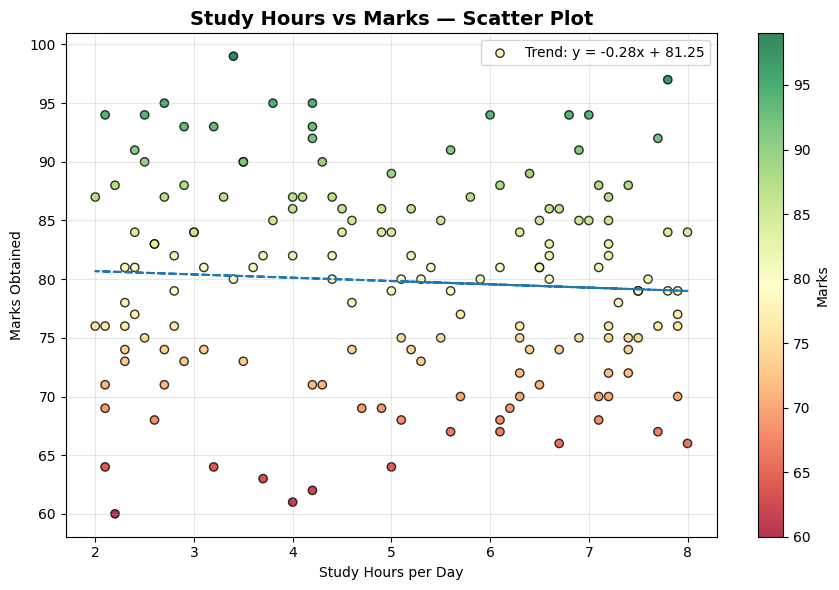

In [5]:
plt.figure(figsize=(9,6))

x = df["study_hours_per_day"]
y = df["percentage"]

# Scatter plot with color gradient
scatter = plt.scatter(
    x, y,
    c=y,
    cmap="RdYlGn",
    edgecolor="black",
    alpha=0.8
)

# Regression Line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, linestyle="--")

# Equation Display
equation = f"Trend: y = {m:.2f}x + {b:.2f}"
plt.legend([equation])

# Titles and Labels
plt.title("Study Hours vs Marks — Scatter Plot", fontsize=14, fontweight="bold")
plt.xlabel("Study Hours per Day")
plt.ylabel("Marks Obtained")

# Color bar
cbar = plt.colorbar(scatter)
cbar.set_label("Marks")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()